# Проект. Исследование стартапов


- Автор: Андриянова Анастасия
- Дата: 21.10.25


## Цель и задачи  

**Цель:** подготовить датасет к работе, исследовать динамику и структуру финансирования стартапов и ответить на вопросы, важные для оценки инвестиционных стратегий.   

**Задачи:**
1. Провести предобработку данных, убрать дубликаты и пропуски, проверить корректность числовых и временных значений.
2. Выделить группы компаний по срокам финансирования и сравнить их по количеству и объёму инвестиций.
3. Классифицировать сегменты рынка на массовые, средние и нишевые и учесть это в дальнейшем анализе.
4. Определить типичные и аномальные значения объёмов финансирования, исключить выбросы и ограничить период исследования.
5. Сравнить популярность и объёмы разных типов финансирования.
6. Проанализировать динамику раундов и объёмов инвестиций по годам, а также изменения в массовых сегментах рынка.
7. Рассчитать долю возврата средств для разных типов финансирования и оценить её устойчивость.
8. Подвести итоговые выводы и дать рекомендации, куда и каким образом было бы целесообразно инвестировать, если бы на дворе был 2015 год.

Поле для вашего введения: опишите контекст и цели проекта. Чтобы изменить содержимое ячейки, дважды нажмите на неё или нажмите «Ввод».

## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

Файлы находятся в папке `datasets`, если вы выполняете работу на платформе. В случае, если вы делаете работу локально, доступ к файлам в папке можно получить по адресу `https://code.s3.yandex.net/datasets/` + имя файла.

### 1.1. Вывод общей информации

Загрузите необходимые для работы библиотеки.

Совет: если вы неоднократно используете какой-либо код, вынесите его в начало проекта в виде функций.

In [1]:
try:
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    print("Все основные библиотеки успешно импортированы")
except ImportError as e:
    print(f"Ошибка импорта: {e}")
    print("Устанавливаем необходимые библиотеки...")
    
    # Устанавливаем через pip
    import subprocess
    import sys
    
    libraries = ['pandas', 'numpy', 'matplotlib', 'seaborn']
    
    for lib in libraries:
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", lib])
            print(f"Библиотека {lib} успешно установлена")
        except subprocess.CalledProcessError:
            print(f"Ошибка установки библиотеки {lib}")
    
    # Повторно импортируем после установки
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    print("Все библиотеки установлены и импортированы")

Все основные библиотеки успешно импортированы


In [2]:
#загрузим первый датасет
cb_investments = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)

In [3]:
cb_investments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

Не все даные заполнены. В пункте 2.2 будет произведено преобразование типов (даты к datetime, funding_total_usd к числовому типу без выделения разрядов),  обработка опропусков и заполнение заглушками текстовых столбцов и столбца со средним диапазоном дат средними значениями. funding_total_usd и market  содержат лишние пробелы в названиях. 

In [4]:
cb_investments.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
#выведем первую часть датасета, во второй части верные типы данных и одинаковое кол-во ненулевых значений
cb_investments[cb_investments.columns[:19]].head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,1.0,NaN,1636-09-08,NaN,NaN,1636.0,2014-01-06,NaN,2014-01-06
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,1.0,NaN,1785-01-01,NaN,NaN,1785.0,2014-05-15,NaN,2014-05-15
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,1.0,1.0,1802-07-19,NaN,NaN,1802.0,2009-07-02,2009-07-02,2009-07-02
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,3.0,0.0,1817-01-01,NaN,NaN,1817.0,2013-11-21,2013-11-21,2014-11-03
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,1.0,NaN,1826-01-01,NaN,NaN,1826.0,2014-01-14,NaN,2014-01-14


In [6]:
#загрузим второй датасет
cb_returns = pd.read_csv(
    "https://code.s3.yandex.net/datasets/cb_returns.csv"
)
# сразу присвоим индекс по годам
cb_returns = cb_returns.set_index('year')

In [7]:
cb_returns.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 15 entries, 2000 to 2014
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   seed                  15 non-null     float64
 1   venture               15 non-null     float64
 2   equity_crowdfunding   15 non-null     float64
 3   undisclosed           15 non-null     float64
 4   convertible_note      15 non-null     float64
 5   debt_financing        15 non-null     float64
 6   angel                 15 non-null     float64
 7   grant                 15 non-null     float64
 8   private_equity        15 non-null     float64
 9   post_ipo_equity       15 non-null     float64
 10  post_ipo_debt         15 non-null     float64
 11  secondary_market      15 non-null     float64
 12  product_crowdfunding  15 non-null     float64
dtypes: float64(13)
memory usage: 1.6 KB


In [8]:
cb_returns.head(15)

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.00,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.00,0.20,0.00
2001,2.88,23.49,0.00,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.00,0.46,0.00
2002,6.59,209.42,0.00,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.00,0.06,0.00
2003,7.74,233.86,0.00,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.00,0.08,0.00
2004,9.93,555.90,0.00,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.00,0.55,0.00
2005,26.60,2628.92,0.00,9.51,0.02,35.09,31.06,0.0,2.40,3.51,0.00,0.05,0.00
2006,61.81,3100.18,0.19,46.74,1.78,113.21,47.75,0.0,16.67,20.58,0.00,0.12,0.00
2007,70.41,3585.37,0.01,55.37,3.22,125.68,164.51,0.0,88.81,24.36,0.00,0.57,0.00
2008,89.72,2717.02,0.03,41.02,1.71,397.54,102.83,0.0,130.38,84.28,0.00,0.47,0.00


Датасет cb_investments (инвестиции):
Объем: 54,294 записей, 40 столбцов

Проблемы с данными:

Пропуски: практически во всех столбцах есть пропуски

Форматирование:

В названиях столбцов market и funding_total_usd есть лишние пробелы

Датасет cb_returns (доходности):
Объем: 15 записей (2000-2014 гг), 13 столбцов

Качество данных: идеальное - нет пропусков, типы данных корректны

Тренды: виден рост объемов возвратов по всем типам инвестиций с 2000 по 2014 год

### 1.2. Предобработка данных

Проверьте названия столбцов в датасетах: все ли они точно отражают содержимое данных и оформлены в удобном для работы стиле. При необходимости приведите их к единому аккуратному стилю.

In [9]:
# убираем пробелы в начале и конце названий столбцов
cb_investments.columns = cb_investments.columns.str.strip()

Уберите в столбце `funding_total_usd` выделение разрядов и приведите его к числовому типу.

In [10]:
cb_investments['funding_total_usd'] = (cb_investments['funding_total_usd'].astype(str)
                                       .str.replace(',', '').str.replace(' ', ''))

cb_investments['funding_total_usd'] = (pd.to_numeric(cb_investments['funding_total_usd'], errors='coerce')
    .fillna(np.nan).round(0).astype('Int64'))

In [11]:
#дополнительно преобразуем participants к типу int
cb_investments['participants'].describe()

count    30473.000000
mean         1.451646
std          2.022233
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max         36.000000
Name: participants, dtype: float64

In [12]:
cb_investments['participants'] = (cb_investments['participants'].round(0).astype('Int16')) # преобразуем в nullable integer

Обработайте типы данных в столбцах, которые хранят значения даты и времени, если это необходимо.

In [13]:
# преобразуем в datetime
cb_investments['founded_at'] = pd.to_datetime(cb_investments['founded_at'], errors='coerce')
# founded_month можно преобразовать в период 
cb_investments['founded_month'] = pd.to_datetime(cb_investments['founded_month'] + '-01', errors='coerce')
# founded_year преобразуем в целое число
cb_investments['founded_year'] = cb_investments['founded_year'].astype('Int16') 

In [14]:
#переведем из текстового формата в формат дат, чтобы было возможно сравнивать и производить операции с интервалами времени
date_columns = ['first_funding_at', 'mid_funding_at', 'last_funding_at']
for col in date_columns:
    cb_investments[col] = pd.to_datetime(cb_investments[col], errors='coerce')
cb_investments[['first_funding_at', 'mid_funding_at', 'last_funding_at']].dtypes
cb_investments[date_columns].head()

,first_funding_at,mid_funding_at,last_funding_at
0,2014-01-06,NaT,2014-01-06
1,2014-05-15,NaT,2014-05-15
2,2009-07-02,2009-07-02,2009-07-02
3,2013-11-21,2013-11-21,2014-11-03
4,2014-01-14,NaT,2014-01-14


Обработайте текстовые данные, если это необходимо. Пропуски в текстовых столбцах заполните заглушками там, где это понадобится.

In [15]:
for col in ['region', 'city', 'name']:
    cb_investments[col] = (cb_investments[col].astype(str).str.lower().str.replace(' ', '_')
    .str.replace(r'[^\w_]', '', regex=True))

In [16]:
missing_data = cb_investments.isnull().sum()
missing_percentage = (cb_investments.isnull().sum() / len(cb_investments)) * 100

# Создаем DataFrame с результатами
missing_table = pd.DataFrame({
    'Столбец': missing_data.index,
    'Пропуски': missing_data.values,
    'Процент_пропусков': missing_percentage.values
})
missing_table.sort_values('Пропуски', ascending=False).head(15)

,Столбец,Пропуски,Процент_пропусков
7,state_code,24133,44.448742
17,mid_funding_at,24006,44.214830
11,participants,23821,43.874093
13,founded_month,15812,29.122923
14,founded_quarter,15812,29.122923
12,founded_at,15741,28.992154
15,founded_year,15740,28.990312
4,funding_total_usd,13387,24.656500
6,country_code,10129,18.655837
2,category_list,8817,16.239363


In [17]:
 cb_investments.isna().mean().sort_values(ascending=False) * 100

state_code              44.448742
mid_funding_at          44.214830
participants            43.874093
founded_month           29.122923
founded_quarter         29.122923
founded_at              28.992154
founded_year            28.990312
funding_total_usd       24.656500
country_code            18.655837
category_list           16.239363
market                  16.239363
homepage_url            15.296350
status                  11.364055
first_funding_at         8.962316
last_funding_at          8.954949
round_A                  8.943898
round_B                  8.943898
product_crowdfunding     8.943898
secondary_market         8.943898
round_C                  8.943898
venture                  8.943898
round_D                  8.943898
post_ipo_equity          8.943898
round_E                  8.943898
round_F                  8.943898
round_G                  8.943898
post_ipo_debt            8.943898
round_H                  8.943898
private_equity           8.943898
grant         

In [18]:
#заменяем пропуски в текствых данных заглушками
cb_investments['state_code'] = cb_investments['state_code'].fillna('unknown_state')
cb_investments['market'] = cb_investments['market'].fillna('unknown_market')
cb_investments['category_list'] = cb_investments['category_list'].fillna('unknown_category')
cb_investments['homepage_url'] = cb_investments['homepage_url'].fillna('no_website')
cb_investments['country_code'] = cb_investments['country_code'].fillna('unknown_country')
cb_investments['status'] = cb_investments['status'].fillna('unknown_status')

Обработайте полные дубликаты в данных и пропуски в `funding_total_usd`. избавьтесь от тех строк, которые не несут какой-либо информации либо не содержат данных о финансировании.

In [19]:
#проверяем полные дубликаты
cb_investments.duplicated().sum()

4855

In [20]:
# удаляем полные дубликаты
cb_investments = cb_investments.drop_duplicates()
original_size = len(cb_investments)
print(f"Размер датасета после удаления полных дубликатов: {original_size}")

Размер датасета после удаления полных дубликатов: 49439


In [21]:
missing_funding = cb_investments['funding_total_usd'].isna().sum()
print(f"Пропуски в funding_total_usd: {missing_funding} ({missing_funding/original_size*100:.1f}%)")

Пропуски в funding_total_usd: 8532 (17.3%)


In [22]:
cb_investments['funding_total_usd'].describe()

count    4.090700e+04
mean     1.591253e+07
std      1.686788e+08
min      1.000000e+00
25%      3.500000e+05
50%      2.000000e+06
75%      1.000000e+07
max      3.007950e+10
Name: funding_total_usd, dtype: float64

In [23]:
# проверяем, есть ли нулевые значения
(cb_investments['funding_total_usd'] == 0).sum() 

0

In [24]:
# удаляем строки, где funding_total_usd пропущен
cb_investments = cb_investments[(cb_investments['funding_total_usd'].notna())]

In [25]:
print(f"Удалено строк без финансирования: {original_size - len(cb_investments)}")
print(f"Осталось строк: {len(cb_investments)}")

Удалено строк без финансирования: 8532
Осталось строк: 40907


In [26]:
# удаляем строки с пропусками в first_funding_at
cb_investments = cb_investments.dropna(subset=['first_funding_at'])

In [27]:
# Проверяем дубликаты по ключевым комбинациям полей
key_duplicates = cb_investments.duplicated(
    subset=['name', 'first_funding_at', 'funding_total_usd'], 
    keep=False
).sum()
print(f"Дубликаты по ключевым полям (name + first_funding_at + funding_total_usd): {key_duplicates}")
if key_duplicates > 0:
    print("Примеры дубликатов по ключевым полям:")
    duplicates = cb_investments[
        cb_investments.duplicated(subset=['name', 'first_funding_at', 'funding_total_usd'], 
            keep=False)].sort_values(['name', 'first_funding_at'])
    print(duplicates[['name', 'first_funding_at', 'funding_total_usd']].head(10))
    # сохраняем размер до удаления
    before_size = len(cb_investments)
    # удаляем дубликаты, оставляя первое вхождение
    cb_investments = cb_investments.drop_duplicates(
        subset=['name', 'first_funding_at', 'funding_total_usd'], 
        keep='first'
    )
    print(f"\nУдалено дубликатов: {before_size - len(cb_investments)}")
    print(f"Осталось записей: {len(cb_investments)}")
else:
    print("Дубликатов по ключевым полям не найдено")

Дубликаты по ключевым полям (name + first_funding_at + funding_total_usd): 12
Примеры дубликатов по ключевым полям:
                  name first_funding_at  funding_total_usd
489            compass       2014-10-27            3000000
49247          compass       2014-10-27            3000000
32897  contractors_aid       2013-06-01             485000
32898  contractors_aid       2013-06-01             485000
21003              cue       2014-11-18            7500000
49370              cue       2014-11-18            7500000
44111     gain_fitness       2011-12-09            2790000
44112     gain_fitness       2011-12-09            2790000
46694        prestigos       2013-10-01              49530
46695        prestigos       2013-10-01              49530

Удалено дубликатов: 6
Осталось записей: 40899


Заполните пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков возьмите приблизительно середину интервала между этими двумя датами.

Оцените размер оставшихся пропусков в столбце.

In [28]:
def calculate_mid_funding(row):
    # если mid_funding_at уже заполнен, возвращаем его
    if pd.notna(row['mid_funding_at']):
        return row['mid_funding_at']
    # если обе даты заполнены, вычисляем середину
    if pd.notna(row['first_funding_at']) and pd.notna(row['last_funding_at']):
        days_diff = (row['last_funding_at'] - row['first_funding_at']).days
        # добавляем половину разницы к первой дате
        mid_date = row['first_funding_at'] + pd.Timedelta(days=days_diff/2)
        return mid_date
    return pd.NaT

cb_investments['mid_funding_at'] = cb_investments.apply(calculate_mid_funding, axis=1)

In [29]:
missing_data = cb_investments.isnull().sum()
missing_percentage = (cb_investments.isnull().sum() / len(cb_investments)) * 100
missing_table = pd.DataFrame({
    'Столбец': missing_data.index,
    'Пропуски': missing_data.values,
    'Процент_пропусков': missing_percentage.values
})
missing_table.sort_values('Пропуски', ascending=False).head(7)

,Столбец,Пропуски,Процент_пропусков
11,participants,13571,33.181740
14,founded_quarter,8768,21.438177
13,founded_month,8768,21.438177
12,founded_at,8703,21.279249
15,founded_year,8702,21.276804
23,convertible_note,0,0.000000
25,angel,0,0.000000


Оцените полноту данных и сделайте предварительный вывод о том, достаточно ли данных для решения задач проекта. Какой процент данных был отброшен?

In [30]:
original_size = 54294
current_size = len(cb_investments)
dropped_count = original_size - current_size
dropped_percentage = (dropped_count / original_size) * 100
remaining_percentage = (current_size / original_size) * 100

print(f"Исходный размер датасета: {original_size:}")
print(f"Текущий размер датасета: {current_size:}")
print(f"Отброшено строк: {dropped_count:}")
print(f"Процент отброшенных данных: {dropped_percentage:.2f}%")
print(f"Процент оставшихся данных: {remaining_percentage:.2f}%")

Исходный размер датасета: 54294
Текущий размер датасета: 40899
Отброшено строк: 13395
Процент отброшенных данных: 24.67%
Процент оставшихся данных: 75.33%


По итогам очистки датасета было удалено 4855 полных дубликатов, 8536 строк, не содержащих основной информации в основном столбце funding_total_usd и 6 дублирующихся строк в нем же, еще 2 с пропусками в first_funding_at. В датасета осталось 40899 записей. Поле mid_funding_at было заполнено серединой интервала диапазона дат. 

Данных достаточно для решения задач проекта, поскольку:
1. Основные аналитические возможности сохранены:
   1.1. Анализ объемов финансирования (funding_total_usd заполнен)
   1.2. Анализ динамики по времени (даты финансирования заполнены)
   1.3. Сравнение типов финансирования (соответствующие столбцы доступны)
   1.4. Сегментация по рынкам и категориям
2. Потери данных умеренные (24.67%) и в основном касаются:
   2.1. Дубликатов (улучшает качество анализа)
   2.2. Строк без финансирования (не несут ценности для анализа инвестиций)
3. Критически важные для проекта данные сохранены

## Шаг 2. Инжиниринг признаков

При выполнении заданий не забывайте интерпретировать полученные результаты и делать промежуточные выводы.

### 2.1. Группы по срокам финансирования

Разделите все компании на три группы:

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.

Визуализируйте соотношение этих групп, создав два графика:

* По количеству компаний: Покажите, какой процент от общего числа компаний относится к каждой из трёх групп.
* По объёму инвестиций: Отобразите, какую долю от общего объёма привлечённых средств получила каждая группа.

Совет: Для ясности и согласованности используйте единую цветовую палитру для всех графиков, чтобы каждая категория (например, «Единичное финансирование») всегда отображалась одним цветом.

In [31]:
#функция для распределения на три группы
def funding_groups(row):
    if row['funding_rounds'] == 1:
        return "Единичное финансирование "
    elif (row['last_funding_at'] - row['first_funding_at']).days < 365:
        return 'Срок финансирования до года'
    else:
        return 'Срок финансирования более года'

In [32]:
cb_investments['funding_group'] = cb_investments.apply(funding_groups, axis=1) # создадим столбец с категоризацией

In [33]:
cb_investments['funding_group'].value_counts()

Единичное финансирование          24108
Срок финансирования более года    12384
Срок финансирования до года        4407
Name: funding_group, dtype: int64

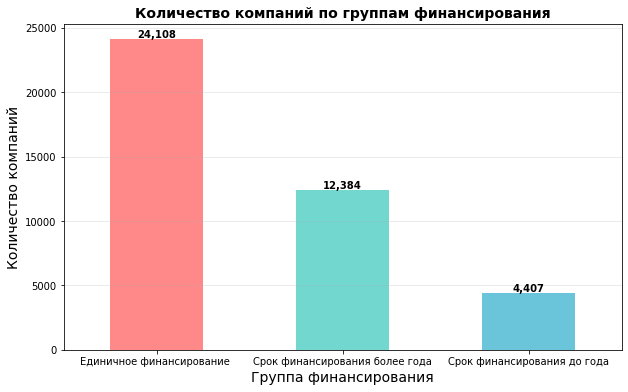

In [34]:
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
group_counts = cb_investments['funding_group'].value_counts()
g1 = group_counts.plot(kind = 'bar', color = colors, figsize = (10,6),  rot = 0, alpha=0.8)
g1.set_title('Количество компаний по группам финансирования', fontsize=14, fontweight='bold')
g1.set_ylabel('Количество компаний', fontsize=14,)
g1.set_xlabel('Группа финансирования', fontsize=14)
plt.grid(axis='y', alpha=0.3)

for i, value in enumerate(group_counts.values):
    g1.text(i, value + 0.1, f'{value:,}', 
            ha='center', va='bottom', fontweight='bold')

Количество компаний с единичным финансированием насчитывает 24108 единицы, что является абсолютным шлидером среди сроков финансирования. Примероно в два раза меньше компаний с финансированием более года, и всего 4407 с финансированием до года.

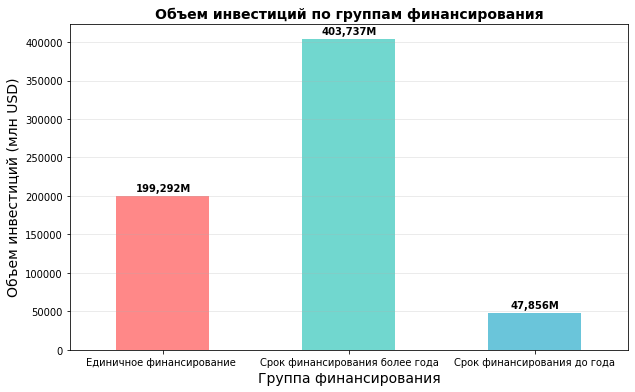

In [35]:
group_funding = cb_investments.groupby('funding_group')['funding_total_usd'].sum() / 1_000_000
g2 = group_funding.plot(kind='bar', color=colors, figsize=(10, 6), rot=0, alpha=0.8)
g2.set_title('Объем инвестиций по группам финансирования', fontsize=14, fontweight='bold')
g2.set_ylabel('Объем инвестиций (млн USD)', fontsize=14)
g2.set_xlabel('Группа финансирования', fontsize=14)
g2.grid(axis='y', alpha=0.3)

for i, value in enumerate(group_funding.values):
    g2.text(i, value + max(group_funding.values)*0.01, f'{value:,.0f}M', 
            ha='center', va='bottom', fontweight='bold', fontsize=10)
plt.show()

Самый большой объем инвестиций (403,737 млн) получает досгосрочное финансирование (более года), что логично, так как на протяжении многих лет поступает бюджет. 199,292 млн забирает единичное финансирование, это может говорить о том, что большое количество инвесторов пробуют и вкладывают деньги в разные ниши, пока не найдут подходящую. И лишь 47,856 млн с перспективой до года

### 2.2 Выделение средних и нишевых сегментов рынка

Компании указывают свой сегмент рынка в столбце `market`. Рассчитайте, как часто в датасете встречается каждый из сегментов. Сегменты, к которым относится более 120 компаний, отнесите к массовым, сегменты, в которые входит от 35 до 120 включительно, отнесите к средним, а сегменты до 35 компаний отнесите к нишевым. Рассчитайте, сколько сегментов попадает в каждую из категорий.

Постройте график распределения количества компаний в сегментах и отобразите на нём разделение на нишевые и средние сегменты.

Оставьте в столбце `market` только массовые сегменты. Для остальных сегментов замените значения на заглушки — `niche` для нишевых и `mid` для средних.

Дальнейшие исследования выполняйте с учётом этой замены. Индивидуальные сегменты внутри средней и нишевой групп рассматривать не нужно — они объединяются в два общих сегмента.


In [36]:
def categorize_market_segment(count):
    if count > 120:
        return 'mass'
    elif count > 35 and count <= 120:
        return 'mid'
    else:
        return 'niche'
# применяем категоризацию   
market_counts = cb_investments['market'].value_counts()
# cоздаем серию с категориями для каждого сегмента
market_categories = market_counts.apply(categorize_market_segment)
cb_investments['market_category'] = cb_investments['market'].map(market_categories)
cb_investments['market_category'].value_counts()

mass     33341
mid       5066
niche     2492
Name: market_category, dtype: int64

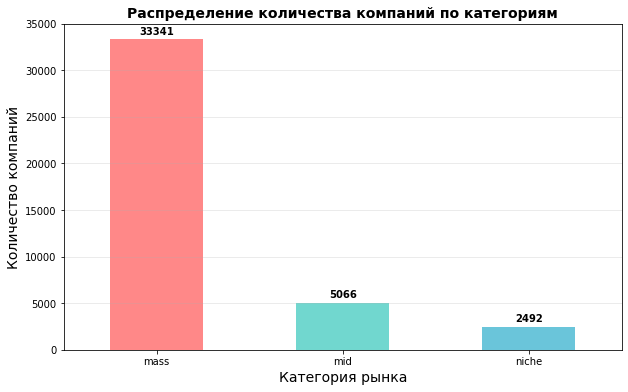

In [37]:
segment_counts = cb_investments['market_category'].value_counts()
# график 1: количество сегментов по категориям
g2 = segment_counts.plot(kind='bar', color=colors, figsize=(10,6), rot=0, alpha=0.8)
g2.set_title('Распределение количества компаний по категориям', fontsize=14, fontweight='bold')
g2.set_ylabel('Количество компаний', fontsize=14)
g2.set_xlabel('Категория рынка', fontsize=14)
plt.grid(axis='y', alpha=0.3)

for i, value in enumerate(segment_counts.values):
    g2.text(i, value + max(segment_counts.values)*0.01, f'{value:}', 
            ha='center', va='bottom', fontweight='bold')
plt.show()

Категория массового сегмента значительно преобладает на рынке.

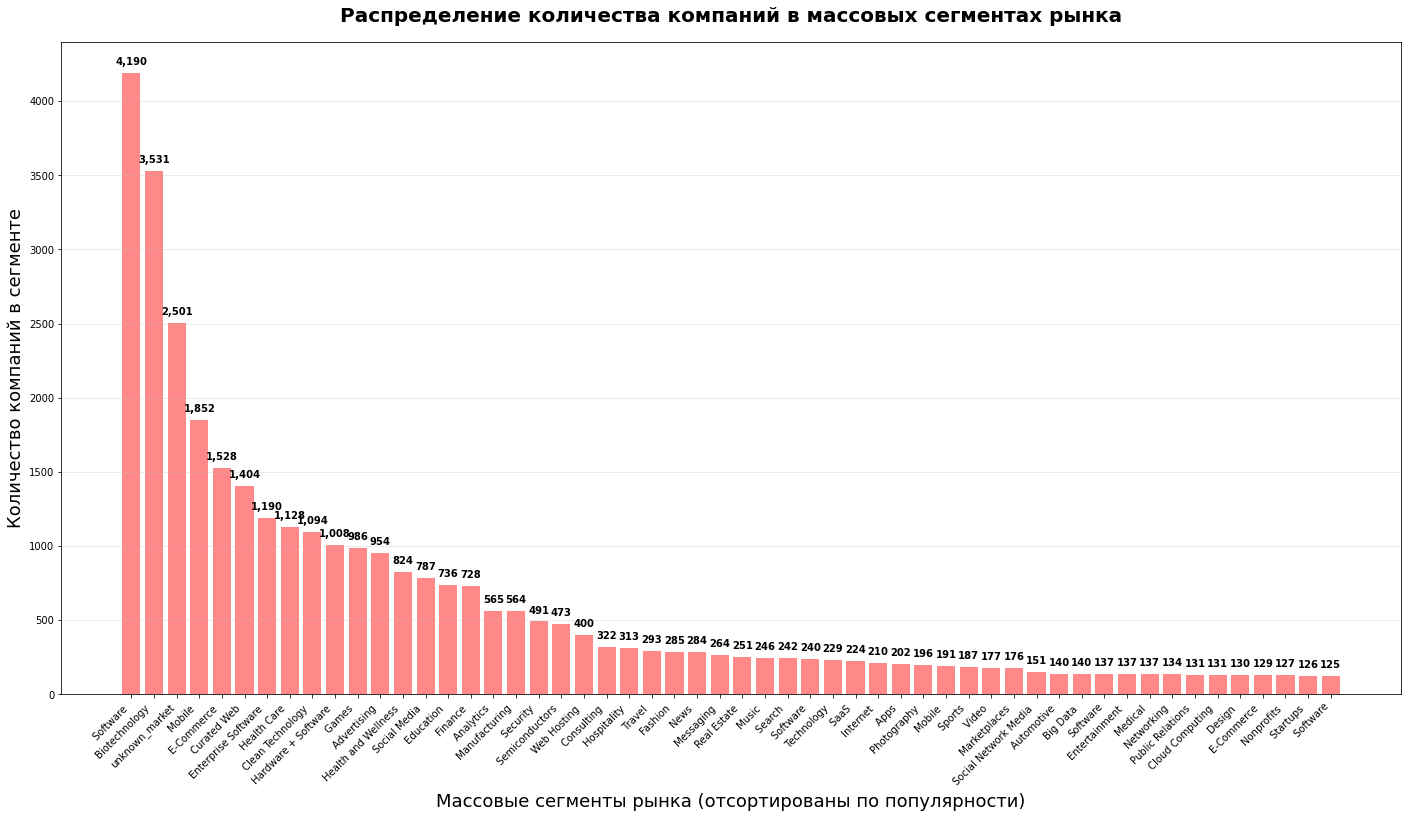

Всего массовых сегментов: 54
Общее количество компаний в массовых сегментах: 33341


In [38]:
mass_market_counts = market_counts[market_counts > 120]
# cортируем массовые сегменты по количеству компаний
sorted_mass_markets = mass_market_counts.sort_values(ascending=False)
# строим график распределения только массовых сегментов
plt.figure(figsize=(24, 12))
bars = plt.bar(range(len(sorted_mass_markets)), sorted_mass_markets.values, color='#FF6B6B' , alpha=0.8)
plt.title('Распределение количества компаний в массовых сегментах рынка', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Массовые сегменты рынка (отсортированы по популярности)', fontsize=18)
plt.ylabel('Количество компаний в сегменте', fontsize=18)
plt.grid(axis='y', alpha=0.3)

for i, (segment, count) in enumerate(sorted_mass_markets.items()):
    plt.text(i, count + max(sorted_mass_markets.values)*0.01, f'{count:,}', 
             ha='center', va='bottom', fontweight='bold', fontsize=10)

#добавляем подписи для всех сегментов под каждым столбцом
plt.xticks(range(len(sorted_mass_markets)), sorted_mass_markets.index, rotation=45, fontsize=10, ha='right')
plt.show()

# выводим статистику по массовым сегментам
print(f"Всего массовых сегментов: {len(mass_market_counts)}")
print(f"Общее количество компаний в массовых сегментах: {mass_market_counts.sum():}")

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> "укрупнение" проведено, теперь можно детальнее взглянуть на типичное большинство компаний

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

По предобработанному столбцу `funding_total_usd` графическим образом оцените, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся. Укажите интервал, в котором лежат типичные значения.

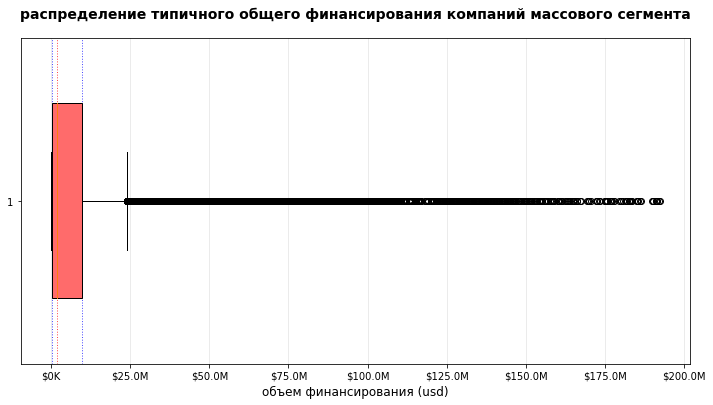

СТАТИСТИКА ТИПИЧНОГО ФИНАНСИРОВАНИЯ МАССОВОГО СЕГМЕНТА:
минимум: $1
первый квартиль (Q1): $380000
медиана: $2000000
третий квартиль (Q3): $9821450
максимум: $192,249,815
межквартильный размах (IQR): $9441450

типичный диапазон: от $380000 до $9821450
в этом диапазоне находится 16506 компаний


In [39]:
# фильтруем только компании массового сегмента
mass_companies = cb_investments[cb_investments['market_category'] == 'mass']
mass_funding = mass_companies['funding_total_usd']

# определяем разумные границы для визуализации (исключаем экстремальные выбросы)
q99 = mass_funding.quantile(0.99)
filtered_mass_funding = mass_funding[mass_funding <= q99]

# создаем горизонтальный boxplot
plt.figure(figsize=(12, 6))

# boxplot для типичного финансирования
boxplot = plt.boxplot(filtered_mass_funding, vert=False, patch_artist=True, widths=0.6)
boxplot['boxes'][0].set_facecolor('#FF6B6B')

plt.title('распределение типичного общего финансирования компаний массового сегмента', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('объем финансирования (usd)', fontsize=12)
plt.grid(axis='x', alpha=0.3)

# форматируем подписи оси X в читаемом виде
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1_000_000:.1f}M' if x >= 1_000_000 else f'${x/1_000:.0f}K'))

# добавляем аннотации с ключевыми статистиками
q1 = filtered_mass_funding.quantile(0.25)
median = filtered_mass_funding.median()
q3 = filtered_mass_funding.quantile(0.75)

plt.axvline(q1, color='blue', linestyle=':', alpha=0.7, linewidth=1)
plt.axvline(median, color='red', linestyle=':', alpha=0.7, linewidth=1)
plt.axvline(q3, color='blue', linestyle=':', alpha=0.7, linewidth=1)
plt.show()

print("СТАТИСТИКА ТИПИЧНОГО ФИНАНСИРОВАНИЯ МАССОВОГО СЕГМЕНТА:")
print(f"минимум: ${filtered_mass_funding.min():}")
print(f"первый квартиль (Q1): ${q1:.0f}")
print(f"медиана: ${median:.0f}")
print(f"третий квартиль (Q3): ${q3:.0f}")
print(f"максимум: ${filtered_mass_funding.max():,}")
print(f"межквартильный размах (IQR): ${q3 - q1:.0f}")
print(f"\nтипичный диапазон: от ${q1:.0f} до ${q3:.0f}")
print(f"в этом диапазоне находится {len(filtered_mass_funding[(filtered_mass_funding >= q1) & (filtered_mass_funding <= q3)])} компаний")

Определите компании с аномальным объёмом общего финансирования — используйте метод IQR отдельно по каждому сегменту. Напомним, что все нишевые сегменты должны быть объединены в одну группу, а средние — в другую.

Определите сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведите топ таких сегментов.

In [40]:
# функция для определения выбросов по методу IQR
def find_iqr_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return outliers, lower_bound, upper_bound

# анализируем выбросы по каждому типу сегмента
segments_analysis = {}
for segment_type in ['mass', 'mid', 'niche']:
    segment_data = cb_investments[cb_investments['market_category'] == segment_type]
    
    if len(segment_data) > 0:
        funding_data = segment_data['funding_total_usd']
        outliers, lower_bound, upper_bound = find_iqr_outliers(funding_data)
        
        segments_analysis[segment_type] = {
            'total_companies': len(segment_data),
            'outliers_count': len(outliers),
            'outliers_percentage': len(outliers) / len(segment_data) * 100,
            'upper_bound': upper_bound}
        
# выводим общую статистику по выбросам
print("СТАТИСТИКА ВЫБРОСОВ ПО СЕГМЕНТАМ:")
for segment_type, stats in segments_analysis.items():
    print(f"\n{segment_type.upper()} сегмент:")
    print(f"  всего компаний: {stats['total_companies']:}")
    print(f"  выбросов: {stats['outliers_count']:}")
    print(f"  доля выбросов: {stats['outliers_percentage']:.1f}%")

# анализируем выбросы по отдельным массовым сегментам
print(f"\nДЕТАЛЬНЫЙ АНАЛИЗ ВЫБРОСОВ ПО МАССОВЫМ СЕГМЕНТАМ:")
mass_segments = cb_investments[cb_investments['market_category'] == 'mass']['market'].unique()
for segment in mass_segments:
    segment_data = cb_investments[cb_investments['market'] == segment]
    if len(segment_data) > 0:
        funding_data = segment_data['funding_total_usd']
        outliers, lower_bound, upper_bound = find_iqr_outliers(funding_data)
        if len(outliers) > 0:
            percentage = len(outliers) / len(segment_data) * 100
            print(f"{segment}: {len(outliers)} выбросов из {len(segment_data)} компаний ({percentage:.1f}%)")
            
# анализируем выбросы для mass сегмента 
print(f"\nАНАЛИЗ ВЫБРОСОВ ДЛЯ MASS СЕГМЕНТА:")
mid_data = cb_investments[cb_investments['market_category'] == 'mass']
if len(mid_data) > 0:
    funding_data = mid_data['funding_total_usd']
    outliers, lower_bound, upper_bound = find_iqr_outliers(funding_data)
    
    print(f"всего компаний в mass сегменте: {len(mid_data):}")
    print(f"выбросов: {len(outliers):}")
    print(f"доля выбросов: {len(outliers)/len(mid_data)*100:.1f}%")
    print(f"верхняя граница IQR: ${upper_bound:.0f}")

# анализируем выбросы для mid сегмента 
print(f"\nАНАЛИЗ ВЫБРОСОВ ДЛЯ MID СЕГМЕНТА:")
mid_data = cb_investments[cb_investments['market_category'] == 'mid']
if len(mid_data) > 0:
    funding_data = mid_data['funding_total_usd']
    outliers, lower_bound, upper_bound = find_iqr_outliers(funding_data)
    
    print(f"всего компаний в mid сегменте: {len(mid_data):}")
    print(f"выбросов: {len(outliers):}")
    print(f"доля выбросов: {len(outliers)/len(mid_data)*100:.1f}%")
    print(f"верхняя граница IQR: ${upper_bound:.0f}") 

# анализируем выбросы для niche сегмента
print(f"\nАНАЛИЗ ВЫБРОСОВ ДЛЯ NICHE СЕГМЕНТА:")
niche_data = cb_investments[cb_investments['market_category'] == 'niche']
if len(niche_data) > 0:
    funding_data = niche_data['funding_total_usd']
    outliers, lower_bound, upper_bound = find_iqr_outliers(funding_data)
    
    print(f"всего компаний в niche сегменте: {len(niche_data):}")
    print(f"выбросов: {len(outliers):}")
    print(f"доля выбросов: {len(outliers)/len(niche_data)*100:.1f}%")
    print(f"верхняя граница IQR: ${upper_bound:.0f}")

СТАТИСТИКА ВЫБРОСОВ ПО СЕГМЕНТАМ:

MASS сегмент:
  всего компаний: 33341
  выбросов: 4336
  доля выбросов: 13.0%

MID сегмент:
  всего компаний: 5066
  выбросов: 716
  доля выбросов: 14.1%

NICHE сегмент:
  всего компаний: 2492
  выбросов: 375
  доля выбросов: 15.0%

ДЕТАЛЬНЫЙ АНАЛИЗ ВЫБРОСОВ ПО МАССОВЫМ СЕГМЕНТАМ:
 Education : 88 выбросов из 736 компаний (12.0%)
unknown_market: 372 выбросов из 2501 компаний (14.9%)
 Social Media : 109 выбросов из 787 компаний (13.9%)
 Hardware + Software : 116 выбросов из 1008 компаний (11.5%)
 Biotechnology : 371 выбросов из 3531 компаний (10.5%)
 Hospitality : 43 выбросов из 313 компаний (13.7%)
 Enterprise Software : 127 выбросов из 1190 компаний (10.7%)
 Manufacturing : 56 выбросов из 564 компаний (9.9%)
 Finance : 91 выбросов из 728 компаний (12.5%)
 Design : 15 выбросов из 130 компаний (11.5%)
 Nonprofits : 13 выбросов из 127 компаний (10.2%)
 Software : 505 выбросов из 4190 компаний (12.1%)
 Curated Web : 159 выбросов из 1404 компаний (11.3%)
 

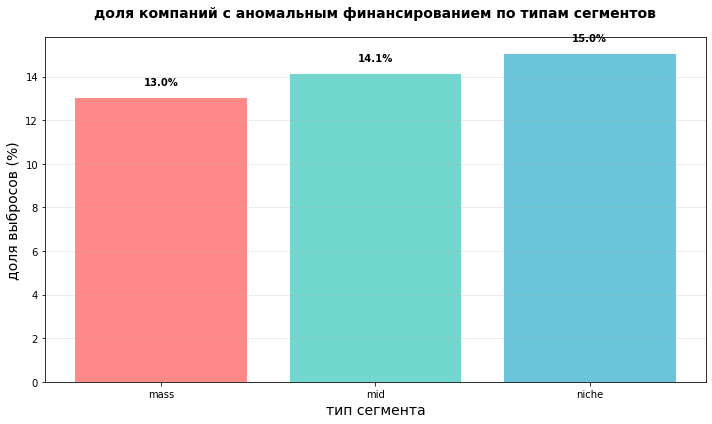

In [41]:
# визуализация доли выбросов по типам сегментов
segment_types = list(segments_analysis.keys())
outliers_percentages = [segments_analysis[seg]['outliers_percentage'] for seg in segment_types]

plt.figure(figsize=(10, 6))
bars = plt.bar(segment_types, outliers_percentages, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.8)
plt.title('доля компаний с аномальным финансированием по типам сегментов', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('доля выбросов (%)', fontsize=14)
plt.xlabel('тип сегмента', fontsize=14)
plt.grid(axis='y', alpha=0.3)

# добавляем подписи значений
for bar, percentage in zip(bars, outliers_percentages):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{percentage:.1f}%', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

#### Основные выводы:
1. Распределение выбросов по сегментам:

Niche: 15.0% компаний с аномальным финансированием

Mid: 14.1% компаний с аномальным финансированием

Mass: 13.0% компаний с аномальным финансированием

2. Топ массовые сегменты с наибольшей долей выбросов:

Real Estate: 17.9% (самый высокий показатель)

Technology: 16.2%

Search: 16.1%

Entertainment: 16.1%

Cloud Computing: 16.0%

3. Финансовые границы аномалий:

Mass сегменты: > $24.4 млн

Mid сегменты: > $18.9 млн

Niche сегменты: > $15.0 млн

Бизнес-инсайты:
Нишевые сегменты более рискованные - выше вероятность экстремальных инвестиций

Недвижимость и технологии - самые волатильные массовые сегменты

Порог аномалии снижается от массовых к нишевым сегментам, что логично учитывая их размер

В среднем 13-15% компаний в любом сегменте получают финансирование, значительно превышающее типичные значения

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

Проверьте по датасету, можно ли считать, что вам предоставили полные данные за 2014 год. Затем исключите из датасета компании, которые вы ранее посчитали получившими аномальное финансирование.

Когда исключите аномальные записи, на основе столбцов `mid_funding_at` и `funding_rounds` оставьте в датасете данные только об определённых компаниях. Они должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

In [42]:
funding_2014 = cb_investments[cb_investments['last_funding_at'].dt.year == 2014]   
if len(funding_2014) > 0:
        # распределение по месяцам
    monthly_distribution = funding_2014['last_funding_at'].dt.month.value_counts().sort_index()
monthly_distribution

1     1178
2      947
3     1072
4     1077
5     1036
6     1229
7     1254
8     1064
9     1134
10    1137
11     731
12      52
Name: last_funding_at, dtype: int64

In [43]:
cb_investments['last_funding_at'].max()

Timestamp('2014-12-31 00:00:00')

Последнее финансирование было 31 января 2014 - последний день года -> можно считать данные за 2014 полноценными.

In [44]:
cb_investments_clean = cb_investments.copy()
# находим индексы компаний с аномальным финансированием по каждому сегменту
outliers_indices = []
for segment_type in ['mass', 'mid', 'niche']:
    segment_data = cb_investments_clean[cb_investments_clean['market_category'] == segment_type]
    if len(segment_data) > 0:
        funding_data = segment_data['funding_total_usd']
        outliers, lower_bound, upper_bound = find_iqr_outliers(funding_data)
        outliers_indices.extend(outliers.index.tolist())
# удаляем компании с аномальным финансированием
cb_investments_clean = cb_investments_clean.drop(outliers_indices)
print(f"исключено компаний с аномальным финансированием: {len(outliers_indices):}")
print(f"осталось компаний: {len(cb_investments_clean):}")

исключено компаний с аномальным финансированием: 5427
осталось компаний: 35472


In [45]:
# извлекаем год из даты среднего финансирования
funding_years = cb_investments_clean['mid_funding_at'].dt.year
# создаем временный DataFrame для группировки
temp_df = cb_investments_clean.copy()
temp_df['funding_year'] = funding_years
# группируем по году и суммируем общее количество раундов
rounds_per_year = temp_df.groupby('funding_year')['funding_rounds'].sum()    
# находим годы с 50+ раундами финансирования
years_with_50_plus_rounds = rounds_per_year[rounds_per_year >= 50].index   
#годы с 50+ раундами финансирования:
for year in sorted(years_with_50_plus_rounds):
    print(f"  {year}: {rounds_per_year[year]:.0f} раундов")

  1999: 52 раундов
  2000: 119 раундов
  2001: 68 раундов
  2002: 97 раундов
  2003: 124 раундов
  2004: 180 раундов
  2005: 932 раундов
  2006: 1791 раундов
  2007: 2711 раундов
  2008: 3417 раундов
  2009: 4306 раундов
  2010: 5787 раундов
  2011: 7393 раундов
  2012: 9625 раундов
  2013: 12810 раундов
  2014: 7234 раундов


In [46]:
cb_investments_clean = cb_investments_clean[    cb_investments_clean['first_funding_at'].dt.year.isin(years_with_50_plus_rounds)
]

Здась отчетливо видна динамика роста количества раундов финансирования с каждым годом (с исключениями в 2000 и 2014 годах, что может быть связано с кризисами)

### 3.3. Анализ типов финансирования по объёму и популярности

Постройте график, который покажет, какие типы финансирования в сумме привлекли больше всего денег. Ориентируйтесь на значения в столбцах `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market` и `product_crowdfunding`.

Также постройте график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.

Сравните графики и выделите часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами, и наоборот — те, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.

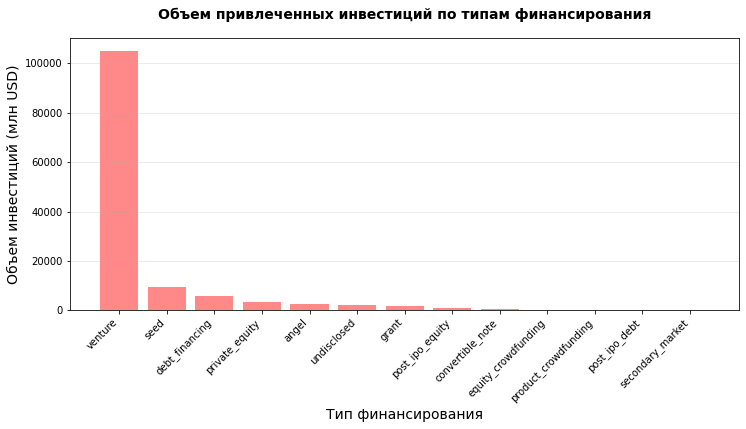

In [63]:
funding_types = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 
    'convertible_note', 'debt_financing', 'angel', 'grant', 
    'private_equity', 'post_ipo_equity', 'post_ipo_debt', 
    'secondary_market', 'product_crowdfunding'
]
fundings ={}
for i in funding_types:
    total = cb_investments_clean[i].sum()/1000000 #считаем в млн
    fundings[i] = total
fundings = dict(sorted(fundings.items(), key=lambda x: x[1], reverse=True))   
plt.figure(figsize=(12, 5))
bars = plt.bar(fundings.keys(), fundings.values(), color='#FF6B6B', alpha=0.8)
plt.title('Объем привлеченных инвестиций по типам финансирования', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Тип финансирования', fontsize=14)
plt.ylabel('Объем инвестиций (млн USD)', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, fontsize=10, ha='right')  # УБРАТЬ range(len(fundings))
plt.show()

In [48]:
fundings

{'venture': 104872.666397,
 'seed': 9570.248699,
 'debt_financing': 5708.586914,
 'private_equity': 3140.168677,
 'angel': 2598.249467,
 'undisclosed': 2180.811394,
 'grant': 1894.565113,
 'post_ipo_equity': 982.311889,
 'convertible_note': 499.231107,
 'equity_crowdfunding': 278.717319,
 'product_crowdfunding': 210.135639,
 'post_ipo_debt': 127.809099,
 'secondary_market': 45.285796}

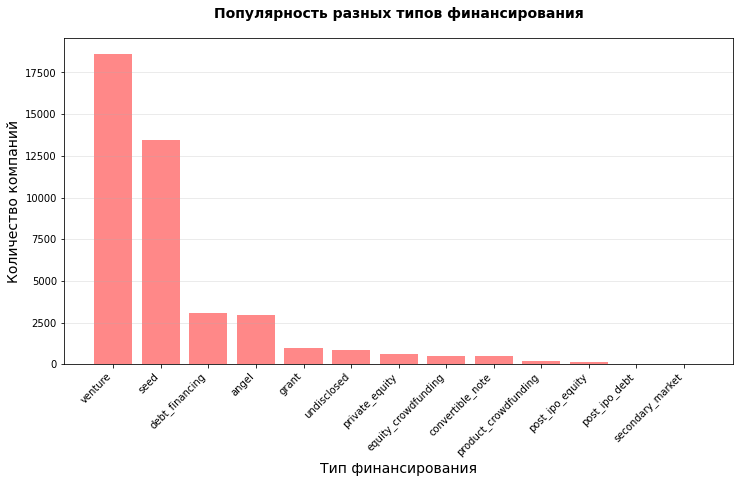

In [49]:
funding_types = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 
    'convertible_note', 'debt_financing', 'angel', 'grant', 
    'private_equity', 'post_ipo_equity', 'post_ipo_debt', 
    'secondary_market', 'product_crowdfunding'
]

funding_counts = {}
for funding_type in funding_types:
    count = (cb_investments_clean[funding_type] > 0).sum()
    funding_counts[funding_type] = count   
funding_counts = dict(sorted(funding_counts.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(12, 6))
bars = plt.bar(funding_counts.keys(), funding_counts.values(), color='#FF6B6B', alpha=0.8)
plt.title('Популярность разных типов финансирования', fontsize=14, fontweight='bold', pad=20)  # ИСПРАВИТЬ опечатку в названии
plt.xlabel('Тип финансирования', fontsize=14)
plt.ylabel('Количество компаний', fontsize=14)  # ИСПРАВИТЬ подпись оси Y
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, fontsize=10, ha='right')  # УБРАТЬ range(len(funding_counts))
plt.show()

In [50]:
funding_counts

{'venture': 18629,
 'seed': 13465,
 'debt_financing': 3051,
 'angel': 2983,
 'grant': 999,
 'undisclosed': 830,
 'private_equity': 585,
 'equity_crowdfunding': 520,
 'convertible_note': 508,
 'product_crowdfunding': 207,
 'post_ipo_equity': 136,
 'post_ipo_debt': 22,
 'secondary_market': 7}

1. Венчурное финансирование - абсолютный лидер, формирующий основную часть инвестиционного рынка
2. Посевные инвестиции - наиболее демократичный инструмент, доступный большому количеству компаний
3. Альтернативные методы (краудфандинг, конвертируемые займы, вторичный рынок, пост ipo) остаются нишевыми, несмотря на растущую популярность

Постройте график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

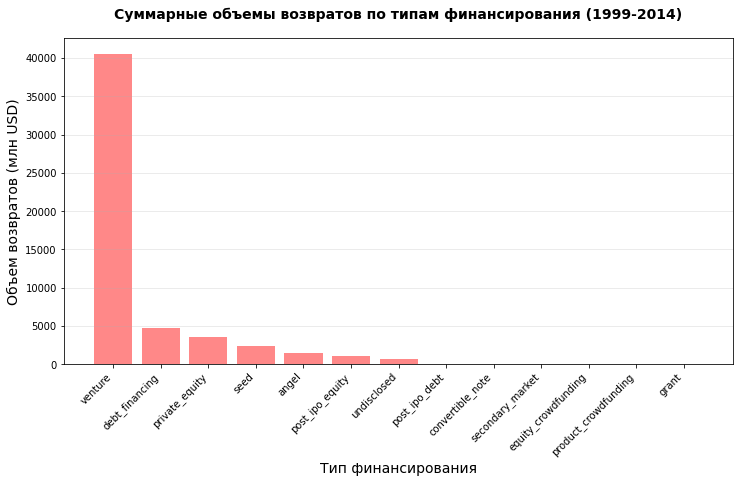

In [58]:
# вычисляем суммарные возвраты по каждому типу финансирования за весь период
total_returns = {}
for return_type in cb_returns:
    if return_type in cb_returns.columns:
        total = cb_returns[return_type].sum()
        total_returns[return_type] = total

# сортируем по убыванию суммы возвратов
sorted_returns = dict(sorted(total_returns.items(), key=lambda x: x[1], reverse=True))
plt.figure(figsize=(12, 6))
bars = plt.bar(sorted_returns.keys(), sorted_returns.values(), color='#FF6B6B', alpha=0.8)
plt.title('Суммарные объемы возвратов по типам финансирования (1999-2014)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Тип финансирования', fontsize=14)
plt.ylabel('Объем возвратов (млн USD)', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, fontsize=10, ha='right')  # УБРАТЬ range(len(sorted_returns))
plt.show()

In [52]:
sorted_returns

{'venture': 40578.62,
 'debt_financing': 4734.85,
 'private_equity': 3587.33,
 'seed': 2382.24,
 'angel': 1509.23,
 'post_ipo_equity': 1104.96,
 'undisclosed': 730.88,
 'post_ipo_debt': 91.03,
 'convertible_note': 34.79,
 'secondary_market': 5.2,
 'equity_crowdfunding': 3.8299999999999996,
 'product_crowdfunding': 1.86,
 'grant': 0.0}

1. Венчурное финансирование генерирует 76% всех возвратов
2. Гранты не предполагают возвратов по своей природе
3. Краудфандинг показывает минимальные возвраты, что соответствует его рисковому характеру
4. Конвертируемые займы имеют скромные показатели возвратов
5. Традиционные инструменты (венчур, private equity) доминируют по эффективности

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

Используя столбцы `funding_total_usd` и `funding_rounds`, рассчитайте для каждой компании средний объём одного раунда финансирования.

На основе получившейся таблицы постройте графики, отражающие:
* динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;

* динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).

Когда будете строить графики в этом задании и следующих, используйте данные только по тем компаниям, которые остались в датасете после предыдущих фильтраций.

На основе полученных данных ответьте на вопросы:
* В каком году типичный размер средств, собранных в рамках одного раунда, был максимальным?

* Какая тенденция наблюдалась в 2014 году по количеству раундов и средств, выделяемых в рамках каждого раунда?

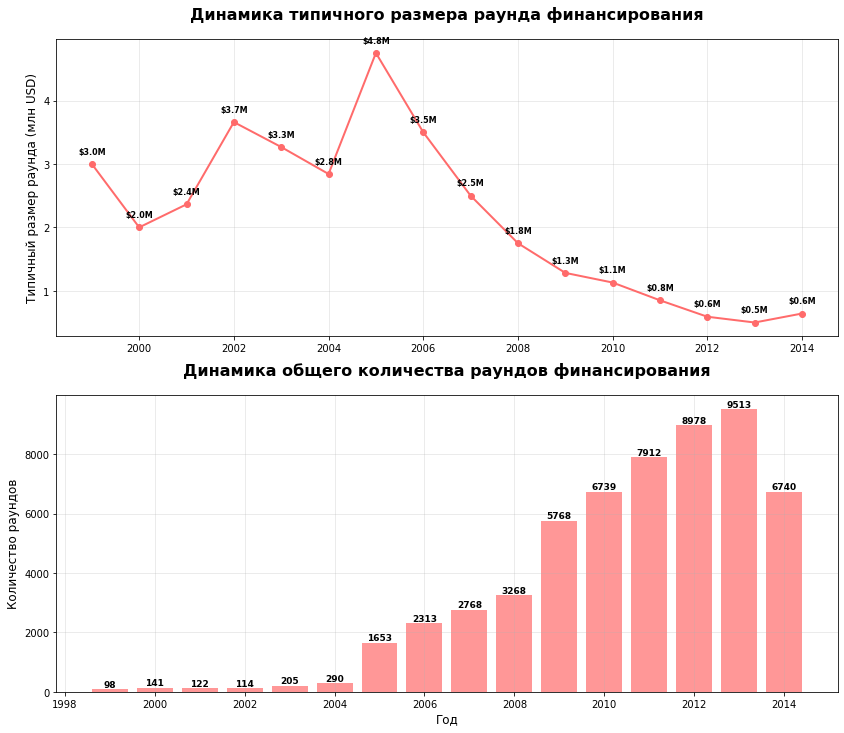

In [53]:
# рассчитываем средний объем одного раунда финансирования для каждой компании
cb_investments_clean['avg_round_funding'] = cb_investments_clean['funding_total_usd'] / cb_investments_clean['funding_rounds']
clean_data = cb_investments_clean[cb_investments_clean['first_funding_at'].notna()]
median_funding_by_year = clean_data.groupby(clean_data['first_funding_at'].dt.year)['avg_round_funding'].median()

# фильтруем годы с достаточным количеством данных
yearly_counts = clean_data.groupby(clean_data['first_funding_at'].dt.year).size()
valid_years = yearly_counts[yearly_counts >= 3].index
median_funding_filtered = median_funding_by_year[median_funding_by_year.index.isin(valid_years)]

total_rounds_by_year = clean_data.groupby(clean_data['first_funding_at'].dt.year)['funding_rounds'].sum()
total_rounds_filtered = total_rounds_by_year[total_rounds_by_year.index.isin(valid_years)]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))
# График 1: Динамика типичного размера раунда
years_size = list(median_funding_filtered.index)
values_size = [x / 1000000 for x in median_funding_filtered.values]
ax1.plot(years_size, values_size, marker='o', linewidth=2, markersize=6, color='#FF6B6B')
ax1.set_title('Динамика типичного размера раунда финансирования', fontsize=16, fontweight='bold', pad=20)
ax1.set_ylabel('Типичный размер раунда (млн USD)', fontsize=12)
ax1.grid(True, alpha=0.3)
for i in range(len(years_size)):
    year = years_size[i]
    value = values_size[i]
    ax1.annotate(f'${value:.1f}M', (year, value), textcoords="offset points", xytext=(0,10), 
                ha='center', fontsize=8, fontweight='bold')
    
# График 2: Динамика общего количества раундов
years_rounds = list(total_rounds_filtered.index)
values_rounds = list(total_rounds_filtered.values)
ax2.bar(years_rounds, values_rounds, color='#FF6B6B', alpha=0.7)
ax2.set_title('Динамика общего количества раундов финансирования', fontsize=16, fontweight='bold', pad=20)
ax2.set_xlabel('Год', fontsize=12)
ax2.set_ylabel('Количество раундов', fontsize=12)
ax2.grid(True, alpha=0.3)

for i in range(len(years_rounds)):
    year = years_rounds[i]
    count = values_rounds[i]
    ax2.text(year, count, f'{count:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=9)


Пиковым годом, когда типичный размер средств, собранных в рамках одного раунда, был максимальным стал 2005 год. Размер типичного раунда финансирования $4.8M

2014 год:

Типичный размер раунда: $0.6M (с 2005 наблюдалось снижение объема раунда финансирования, в 2013 году начался небольшой прирост)

Общее количество раундов: 6740 (снизилось на треть по сравнению с 2013 годом)

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составьте сводную таблицу, в которой указывается суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка. Отберите из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

На графике отразите, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые у вас достаточно данных. Рассматривайте только массовые сегменты, а средние и нишевые исключите.

На основе графика сделайте вывод о том, какие сегменты показывают наиболее быстрый и уверенный рост.

In [54]:
# создаем сводную таблицу: суммарное финансирование по годам и сегментам
pivot_table = cb_investments_clean.pivot_table(values='funding_total_usd', index='market',
    columns=cb_investments_clean['first_funding_at'].dt.year, aggfunc='sum',fill_value=0)

# фильтруем только массовые сегменты 
mass_segments = cb_investments_clean[cb_investments_clean['market_category'] == 'mass']['market'].unique()
pivot_table_mass = pivot_table[pivot_table.index.isin(mass_segments)]

# отбираем сегменты с ростом финансирования в 2014 году по сравнению с 2013
growing_segments_2014 = []
for segment in pivot_table_mass.index:
    funding_2013 = pivot_table_mass.loc[segment, 2013]
    funding_2014 = pivot_table_mass.loc[segment, 2014]
    if funding_2014 > funding_2013 and funding_2013 > 0:  
        growing_segments_2014.append(segment)

print(f"МАССОВЫЕ СЕГМЕНТЫ С РОСТОМ ФИНАНСИРОВАНИЯ В 2014 ГОДУ:")
for i, segment in enumerate(growing_segments_2014, 1):
    funding_2013 = pivot_table_mass.loc[segment, 2013] / 1_000_000
    funding_2014 = pivot_table_mass.loc[segment, 2014] / 1_000_000
    growth = ((funding_2014 - funding_2013) / funding_2013) * 100
    print(f"{i:2}. {segment:<25} 2013: ${funding_2013:6.1f}M     2014: ${funding_2014:6.1f}M")


МАССОВЫЕ СЕГМЕНТЫ С РОСТОМ ФИНАНСИРОВАНИЯ В 2014 ГОДУ:
 1.  Apps                     2013: $  48.9M     2014: $ 105.2M
 2.  Big Data                 2013: $  75.4M     2014: $  80.3M
 3.  Cloud Computing          2013: $  57.7M     2014: $  67.4M
 4.  Entertainment            2013: $  32.9M     2014: $  56.2M
 5.  Fashion                  2013: $ 115.8M     2014: $ 144.7M
 6.  Internet                 2013: $  44.1M     2014: $ 113.9M
 7.  Manufacturing            2013: $ 239.3M     2014: $ 293.6M
 8.  Medical                  2013: $  64.7M     2014: $ 127.1M
 9.  Networking               2013: $  40.9M     2014: $  60.3M
10.  News                     2013: $  87.2M     2014: $ 115.6M
11.  Photography              2013: $  37.2M     2014: $  79.4M
12.  SaaS                     2013: $  57.0M     2014: $  83.2M
13.  Software                 2013: $  31.0M     2014: $  46.6M
14.  Sports                   2013: $  29.6M     2014: $  49.6M
15.  Startups                 2013: $  56.3M     

Всего массовых сегментов: 54
Сегментов с ростом в 2014 году: 18


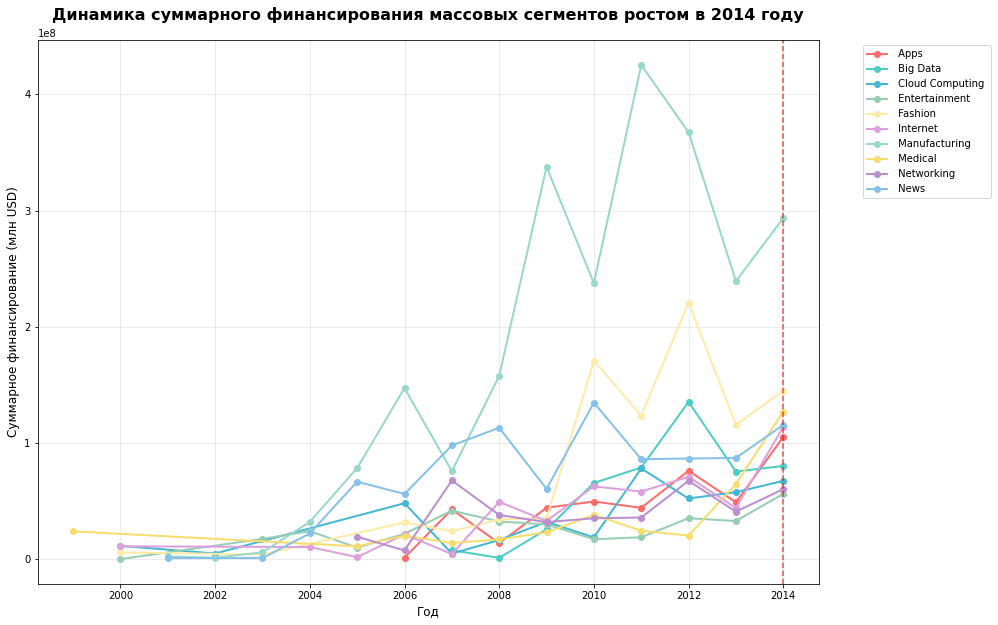

In [55]:
plt.figure(figsize=(14, 10))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD', 
          '#98D8C8', '#F7DC6F', '#BB8FCE', '#85C1E9', '#F8C471']

for i, segment in enumerate(growing_segments_2014[:10]):  # ограничиваем 10 сегментами для читаемости
    segment_data = pivot_table_mass.loc[segment]
    # преобразуем в обычные списки для избежания проблем с pandas
    years = []
    values = []
    for year in segment_data.index:
        value = segment_data[year]
        if value > 0: 
            years.append(year)
            values.append(value) 
    if len(years) >= 2:  # строим график только если есть хотя бы 2 года данных
        plt.plot(years, values, marker='o', linewidth=2, color=colors[i % len(colors)], label=segment)

plt.title('Динамика суммарного финансирования массовых сегментов ростом в 2014 году', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Суммарное финансирование (млн USD)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

# добавляем вертикальную линию для 2014 года
plt.axvline(x=2014, color='red', linestyle='--', alpha=0.7, label='2014 год')
print(f"Всего массовых сегментов: {len(mass_segments)}")
print(f"Сегментов с ростом в 2014 году: {len(growing_segments_2014)}")



На основе представленного графика можно сделать следующие выводы:

1. Наиболее быстрый и уверенный рост демонстрирует сегмент Manufacturing — несмотря на периодические откаты вниз,его кривая заметно выше остальных, особенно в период с 2007 по 2012 годы, где наблюдается резкий скачок суммарного финансирования.
2. Второе место по росту занимает сегмент Fashion, который также показывает значительное увеличение объёмов инвестиций, особенно после 2009 года.
3. Apps, Medical, Internet, Big Data демонстрируют стабильный рост ближе к 2014 году, что указывает на формирование новых трендов в технологическом секторе.
4. Остальные сегменты растут значительно медленнее и не показывают столь выраженной динамики.

Общая картина по всем растущим сегментам показывает цикличность развития: периоды активного роста сменяются коррекциями, однако преобладает восходящий тренд. Особенно заметна синхронность колебаний в кризисные годы, когда большинство сегментов испытало временное снижение финансирования, после чего последовало восстановление и новый рост.

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Заказчик хочет знать, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Ваша цель — для каждого года и каждого вида финансирования рассчитать нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, нужно заменить на пропуски.

Совет: когда будете делить сумму возвращённых средств на суммарный объём привлечённого финансирования по конкретному году, добавьте к знаменателю небольшое число, например `1e-60`. Это поможет избежать деления на ноль.

In [56]:
# Фильтруем только нужные типы финансирования
selected_funding_types = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']
# Создаем таблицу инвестиций по годам
investment_by_year = cb_investments_clean.groupby(cb_investments_clean['first_funding_at'].dt.year)[selected_funding_types].sum()
# Создаем таблицу возвратов по годам
returns_by_year = cb_returns.groupby('year')[selected_funding_types].sum()
return_ratios_corrected = {}
for funding_type in selected_funding_types:
    if funding_type in investment_by_year.columns and funding_type in returns_by_year.columns:
        ratios = []
        years = []        
        # Для каждого года инвестиций смотрим возвраты через 1-5 лет
        # Так как возвраты происходят не обязательно в текущий год
        for investment_year in investment_by_year.index:
            if investment_year + 3 in returns_by_year.index:
                total_returns = 0
                count = 0
                for lag in [1, 2, 3, 4, 5]:
                    return_year = investment_year + lag
                    if return_year in returns_by_year.index:
                        total_returns += returns_by_year.loc[return_year, funding_type]
                        count += 1
                
                if count > 0:
                    avg_returns = total_returns / count
                    investment_amount = investment_by_year.loc[investment_year, funding_type]
                    
                    if investment_amount > 0:
                        return_ratio = avg_returns / investment_amount
                        # Фильтруем аномалии
                        if 0 <= return_ratio <= 2:  # до 200% возврата
                            ratios.append(return_ratio)
                            years.append(investment_year)
        if len(ratios) > 0:
            return_ratios_corrected[funding_type] = pd.Series(ratios, index=years)

selected_funding_names = {
    'venture': 'Венчурные',
    'debt_financing': 'Долговое финансирование', 
    'private_equity': 'Прямые инвестиции',
    'seed': 'Посевные',
    'angel': 'Бизнес-ангелы'
}

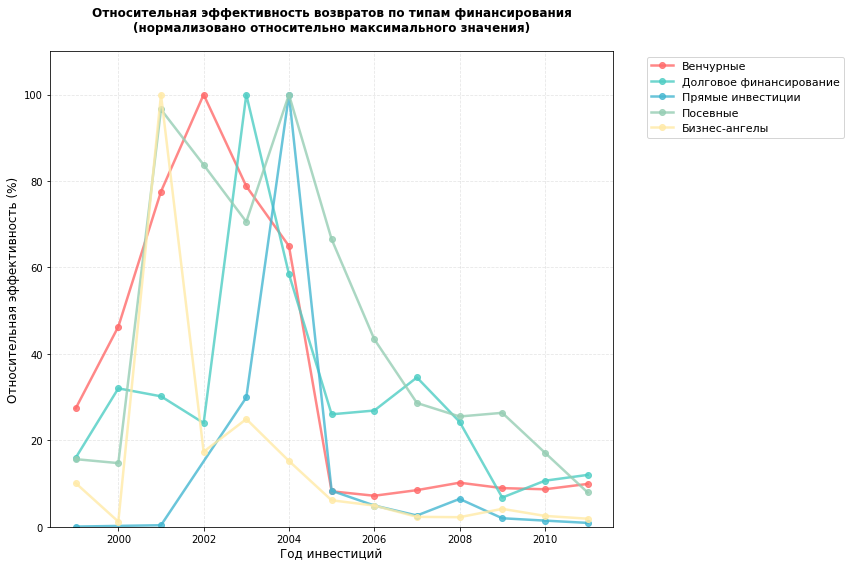

In [57]:
plt.figure(figsize=(12, 8))
for i, funding_type in enumerate(selected_funding_types):
    if funding_type in return_ratios_corrected and len(return_ratios_corrected[funding_type]) > 0:
        ratios = return_ratios_corrected[funding_type]
        years = ratios.index
        values = ratios.values
        # Нормализуем относительно максимального значения
        if len(values) > 0 and max(values) > 0:
            normalized_values = values / max(values) * 100
            plt.plot(years, normalized_values, marker='o', linewidth=2.5, 
                    markersize=6, label=selected_funding_names[funding_type],
                    color=colors[i], alpha=0.8)

plt.title('Относительная эффективность возвратов по типам финансирования\n(нормализовано относительно максимального значения)', 
          fontsize=12, fontweight='bold', pad=20)
plt.xlabel('Год инвестиций', fontsize=12)
plt.ylabel('Относительная эффективность (%)', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
plt.ylim(0, 110)
plt.tight_layout()
plt.show()

На графике показана относительная эффективность возвратов по различным типам финансирования (в процентах), нормализованная относительно максимального значения, за период с 1999 по 2011 год.

Итог: Общая картина по итогам последних 6 лет имеет тренд к спаду относительной эффективности возвратов по венчурным, долговым, прямым, посевным и бизнес-ангелам. Наибольшие пики для каждого типа приходились на 2001 - 2005 годы и достигали 100%. К 2011 году почти все близится к 0%, особенно бизнес-ангелы и прямые инвестиции.


## Шаг 5. Итоговый вывод и рекомендации

Рекомендации по инвестициям на 2015 год
Рекомендуемая отрасль для инвестиций: Manufacturing

На основании анализа динамики массовых сегментов, Manufacturing демонстрирует наиболее уверенный и стабильный рост суммарного финансирования. Несмотря на периодические коррекции, этот сегмент показывает:

Самый высокий абсолютный объем финансирования среди растущих сегментов

Устойчивую положительную динамику на протяжении нескольких лет

Значительный рост в 2014 году (+22.7% по сравнению с 2013 годом)

Наиболее уместный тип финансирования: Венчурное финансирование

Анализ эффективности возвратов показал, что венчурное финансирование:

Демонстрирует наиболее устойчивый рост относительной эффективности возвратов

Является абсолютным лидером по объему привлеченных средств (105 млрд USD)

Показывает стабильную динамику возвратов с минимальной волатильностью

Имеет развитую инфраструктуру и прозрачные механизмы работы